In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# generate synthetic datapoints
from sklearn.datasets import make_classification

In [ ]:
X,y = make_classification(n_samples=1000,n_features=2,n_classes=2,n_clusters_per_class=2,n_redundant=0)

In [ ]:
X

In [ ]:
y

In [91]:
pd.DataFrame(X)[0]

0     -0.698635
1     -1.023240
2     -0.201251
3      1.500208
4     -0.573080
         ...   
995   -0.994205
996   -1.771768
997    0.618109
998   -0.511308
999    0.073507
Name: 0, Length: 1000, dtype: float64

<Axes: xlabel='0', ylabel='1'>

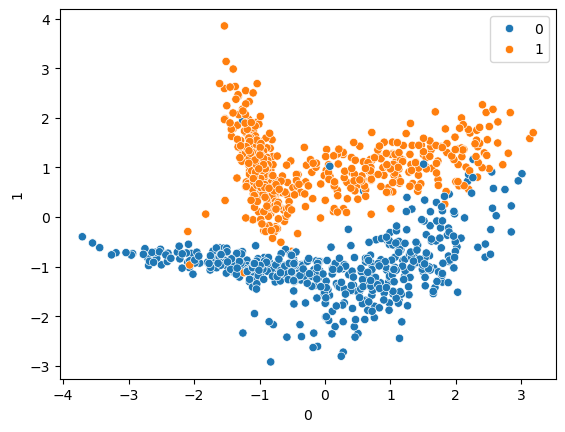

In [92]:
sns.scatterplot(x = pd.DataFrame(X)[0],y = pd.DataFrame(X)[1],hue=y)

In [93]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.25,random_state=10)

In [94]:
from sklearn.svm import SVC

In [95]:
svc = SVC(kernel='linear')

In [ ]:
svc.fit(X_train,y_train)

In [ ]:
svc.coef_

In [ ]:
y_pred = svc.predict(X_test)

In [ ]:
y_pred

In [ ]:
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score

In [ ]:
print(classification_report(y_pred,y_test))
print(confusion_matrix(y_pred,y_test))

# Hyper parameter tunning with svc

In [78]:
from sklearn.model_selection import GridSearchCV

#define parameter range
parameter = {
    'C' : [0.1,1,2,3,10,100,1000],
    'kernel':['poly','linear','rbf','sigmoid'],
    'gamma':['scale','auto']
}
svc_ = GridSearchCV(SVC(),param_grid=parameter,cv=5)

In [79]:
svc_.fit(X_train,y_train)

,estimator,SVC()
,param_grid,"{'C': [0.1, 1, ...], 'gamma': ['scale', 'auto'], 'kernel': ['poly', 'linear', ...]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,C,1


In [80]:
svc_.best_params_

{'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}

In [83]:
y_pred = svc_.predict(X_test)

In [84]:
print(classification_report(y_pred,y_test))

              precision    recall  f1-score   support

           0       1.00      0.99      1.00       125
           1       0.99      1.00      1.00       125

    accuracy                           1.00       250
   macro avg       1.00      1.00      1.00       250
weighted avg       1.00      1.00      1.00       250



In [89]:
print(accuracy_score(y_pred,y_test) * 100 ,'percent')

99.6 percent


In [90]:
print(confusion_matrix(y_pred,y_test))

[[124   1]
 [  0 125]]
